In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pandas.tseries.offsets import MonthEnd

from cat_whim.config import RAW_DATA_DIR

data_tau = RAW_DATA_DIR / "UCBERKELEY_TAUPVC_6MM_17Jul2024.csv"
data_amy = RAW_DATA_DIR / "UCBERKELEY_AMY_6MM_17Jul2024.csv"

df_tau = pd.read_csv(data_tau)
df_amy = pd.read_csv(data_amy)

ModuleNotFoundError: No module named 'cat_whim'

(array([701., 491.,   0., 280.,   0., 126., 105.,   0.,  41.,   1.]),
 array([1. , 1.6, 2.2, 2.8, 3.4, 4. , 4.6, 5.2, 5.8, 6.4, 7. ]),
 <BarContainer object of 10 artists>)

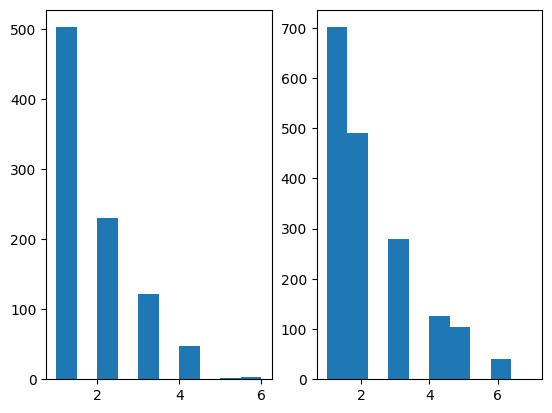

In [ ]:
plt.subplot(121)
plt.hist(df_tau.groupby("PTID")["SCANDATE"].describe()["count"])
plt.subplot(122)
plt.hist(df_tau.groupby("PTID")["SCANDATE"].describe()["count"])

In [ ]:
# Ensure the Date columns are in datetime format
df_tau['Date'] = pd.to_datetime(df_tau['SCANDATE'])
df_amy['Date'] = pd.to_datetime(df_amy['SCANDATE'])

# Merge on PTID
df_merged = pd.merge(df_tau, df_amy, on='PTID', suffixes=('_tau', '_amy'))

# Filter based on the date condition
df_filtered = df_merged[(df_merged['Date_tau'] - MonthEnd(3) <= df_merged['Date_amy']) & 
                        (df_merged['Date_tau'] + MonthEnd(3) >= df_merged['Date_amy'])].copy()

(array([563.,   0.,   0., 209.,   0.,   0.,  52.,   0.,   0.,   3.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

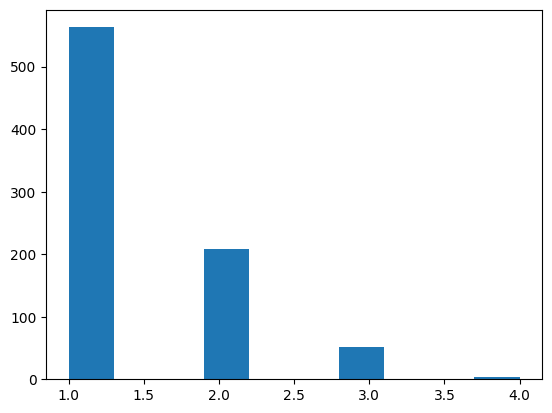

In [ ]:
plt.hist(df_filtered.groupby("PTID")["Date_tau"].describe(datetime_is_numeric=True)["count"])

In [ ]:
df1.columns[:]

,LONIUID,RID,VISCODE,SITEID,PTID,SCANDATE,PROCESSDATE,TRACER,TRACER_SUVR_WARNING,META_TEMPORAL_SUVR,...,RIGHT_PUTAMEN_SUVR,RIGHT_PUTAMEN_VOLUME,RIGHT_THALAMUS_PROPER_SUVR,RIGHT_THALAMUS_PROPER_VOLUME,RIGHT_VENTRALDC_SUVR,RIGHT_VENTRALDC_VOLUME,RIGHT_VESSEL_SUVR,RIGHT_VESSEL_VOLUME,update_stamp,Date
0,I1594604,21,init,11,011_S_0021,2018-02-02,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,1.267,...,1.593,4225.0,1.234,5781.0,1.651,3422.0,NaN,14.0,2024-02-22 12:35:22.0,2018-02-02
1,I1596177,31,init,23,023_S_0031,2018-04-24,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,1.424,...,1.648,5712.0,1.219,6261.0,1.712,2959.0,NaN,6.0,2024-02-22 12:35:22.0,2018-04-24
2,I1596172,31,y1,23,023_S_0031,2019-04-23,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,1.299,...,1.496,5967.0,1.112,5947.0,1.538,3008.0,NaN,8.0,2024-02-22 12:35:22.0,2019-04-23
3,I1598898,56,init,67,067_S_0056,2018-02-20,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,1.438,...,2.066,4024.0,1.477,6595.0,1.710,3646.0,NaN,42.0,2024-02-22 12:35:22.0,2018-02-20
4,I1598985,56,y1,67,067_S_0056,2019-01-10,2022-09-02,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,1.366,...,1.904,4155.0,1.482,6386.0,1.736,3681.0,NaN,39.0,2024-02-22 12:35:22.0,2019-01-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540,I1640013,7105,bl,35,035_S_7105,2022-10-25,2023-05-26,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,2.069,...,1.787,4319.0,1.086,7878.0,1.461,3735.0,NaN,NaN,2024-02-22 12:35:22.0,2022-10-25
1541,I1648618,7114,bl,33,033_S_7114,2022-12-06,2023-05-26,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,1.210,...,1.361,4609.0,1.182,6901.0,1.521,3828.0,NaN,22.0,2024-02-22 12:35:22.0,2022-12-06
1542,I10279040,7117,bl,82,082_S_7117,2023-02-07,2023-12-08,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,1.241,...,1.350,4608.0,1.238,6951.0,1.408,3732.0,NaN,15.0,2024-02-22 12:35:22.0,2023-02-07
1543,I10239398,7121,bl,35,035_S_7121,2023-05-10,2023-09-28,FTP,DO NOT COMPARE SUVRs ACROSS TRACERS,1.289,...,1.664,4434.0,1.337,7487.0,1.538,4058.0,NaN,47.0,2024-02-22 12:35:22.0,2023-05-10
